In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

In [130]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Yogita\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [131]:
df = pd.read_csv("movies.csv")
df.head()

,rank,movie_id,title,year,link,imbd_votes,imbd_rating,certificate,duration,genre,...,director_id,director_name,writer_id,writer_name,storyline,user_id,user_name,review_id,review_title,review_content
0,1,tt0111161,The Shawshank Redemption,1994,https://www.imdb.com/title/tt0111161,"2,711,075",9.3,R,2h 22m,Drama,...,nm0001104,Frank Darabont,"nm0000175,nm0001104","Stephen King,Frank Darabont","Over the course of several years, two convicts...","ur16161013,ur15311310,ur0265899,ur16117882,ur1...","hitchcockthelegend,Sleepin_Dragon,EyeDunno,ale...","rw2284594,rw6606154,rw1221355,rw1822343,rw1288...","Some birds aren't meant to be caged.,An incred...",The Shawshank Redemption is written and direct...
1,2,tt0068646,The Godfather,1972,https://www.imdb.com/title/tt0068646,"1,882,829",9.2,R,2h 55m,"Crime,Drama",...,nm0000338,Francis Ford Coppola,"nm0701374,nm0000338","Mario Puzo,Francis Ford Coppola",The aging patriarch of an organized crime dyna...,"ur24740649,ur86182727,ur15794099,ur15311310,ur...","CalRhys,andrewburgereviews,gogoschka-1,Sleepin...","rw3038370,rw4756923,rw4059579,rw6568526,rw1897...","The Pinnacle Of Flawless Films!,An offer so go...",'The Godfather' is the pinnacle of flawless fi...
2,3,tt0468569,The Dark Knight,2008,https://www.imdb.com/title/tt0468569,"2,684,051",9.0,PG-13,2h 32m,"Action,Crime,Drama",...,nm0634240,Christopher Nolan,"tt0468569,nm0634300,nm0634240,nm0275286,tt0468569","Writers,Jonathan Nolan,Christopher Nolan,David...",When the menace known as the Joker wreaks havo...,"ur87850731,ur1293485,ur129557514,ur12449122,ur...","MrHeraclius,Smells_Like_Cheese,dseferaj,little...","rw5478826,rw1914442,rw6606026,rw1917099,rw5170...","The Dark Knight,The Batman of our dreams! So m...","Confidently directed, dark, brooding, and pack..."
3,4,tt0071562,The Godfather Part II,1974,https://www.imdb.com/title/tt0071562,"1,285,350",9.0,R,3h 22m,"Crime,Drama",...,nm0000338,Francis Ford Coppola,"nm0000338,nm0701374","Francis Ford Coppola,Mario Puzo",The early life and career of Vito Corleone in ...,"ur0176092,ur0688559,ur92260614,ur0200644,ur117...","Nazi_Fighter_David,tfrizzell,umunir-36959,DanB...","rw0135607,rw0135487,rw5049900,rw0135526,rw0135...",Breathtaking in its scope and tragic grandeur....,"Coppola's masterpiece is rivaled only by ""The ..."
4,5,tt0050083,12 Angry Men,1957,https://www.imdb.com/title/tt0050083,"800,954",9.0,Approved,1h 36m,"Crime,Drama",...,nm0001486,Sidney Lumet,nm0741627,Reginald Rose,The jury in a New York City murder trial is fr...,"ur1318549,ur0643062,ur0688559,ur20552756,ur945...","uds3,tedg,tfrizzell,TheLittleSongbird,henrique...","rw0060044,rw0060025,rw0060034,rw2262425,rw5448...","The over-used term ""classic movie"" really come...",This once-in-a-generation masterpiece simply h...


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rank            250 non-null    int64  
 1   movie_id        250 non-null    object 
 2   title           250 non-null    object 
 3   year            250 non-null    int64  
 4   link            250 non-null    object 
 5   imbd_votes      250 non-null    object 
 6   imbd_rating     250 non-null    float64
 7   certificate     249 non-null    object 
 8   duration        250 non-null    object 
 9   genre           250 non-null    object 
 10  cast_id         250 non-null    object 
 11  cast_name       250 non-null    object 
 12  director_id     250 non-null    object 
 13  director_name   250 non-null    object 
 14  writer_id       250 non-null    object 
 15  writer_name     250 non-null    object 
 16  storyline       250 non-null    object 
 17  user_id         250 non-null    obj

In [133]:
data = df[['year', 'imbd_votes', 'imbd_rating',
           'duration', 'genre', 'certificate',
           'review_content']]

In [134]:
data['imbd_votes'] = data['imbd_votes'].str.replace(',', '')
data['imbd_votes'] = pd.to_numeric(data['imbd_votes'], errors='coerce')

In [135]:
import re

def convert_duration(x):
    try:
        x = str(x)
        if 'min' in x:
            return int(re.findall(r'\d+', x)[0])
        elif 'h' in x:
            hours = re.findall(r'(\d+)h', x)
            minutes = re.findall(r'(\d+)m', x)
            h = int(hours[0]) if hours else 0
            m = int(minutes[0]) if minutes else 0
            return h * 60 + m
        else:
            return np.nan
    except:
        return np.nan
data['duration'] = data['duration'].apply(convert_duration)

In [136]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

data['clean_review'] = data['review_content'].apply(clean_text)

In [137]:
data.dropna(subset=['imbd_votes', 'imbd_rating', 'duration', 'clean_review'], inplace=True)

In [138]:
data['genre'] = data['genre'].str.split(',')
data = data.explode('genre')
data['genre'] = data['genre'].str.strip()

data = pd.get_dummies(data, columns=['genre'])

In [139]:
data['certificate'] = data['certificate'].astype('category').cat.codes

In [140]:
sia = SentimentIntensityAnalyzer()

data['sentiment_score'] = data['clean_review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [141]:
data['success'] = (
    (data['imbd_rating'] > 7) &
    (data['imbd_votes'] > data['imbd_votes'].median())
).astype(int)

In [142]:
features = ['year', 'imbd_rating', 'duration', 'certificate', 'sentiment_score']

# Add genre columns
genre_cols = [col for col in data.columns if 'genre_' in col]
features.extend(genre_cols)

X = data[features]
y = data['success']

In [143]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [144]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

model = grid.best_estimator_

In [153]:
y_pred = model.predict(X_test)

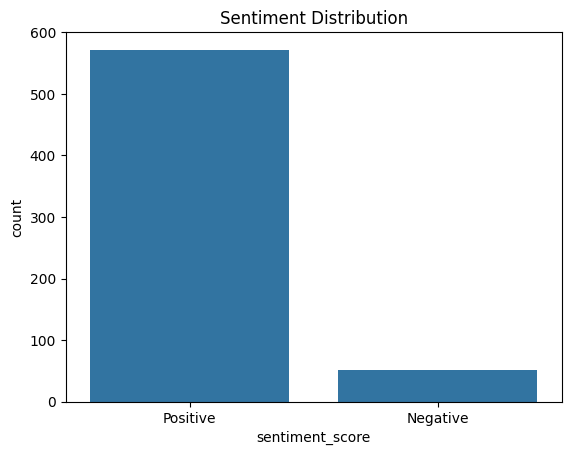

In [154]:
sns.countplot(x=data['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative'))

plt.title("Sentiment Distribution")
plt.show()

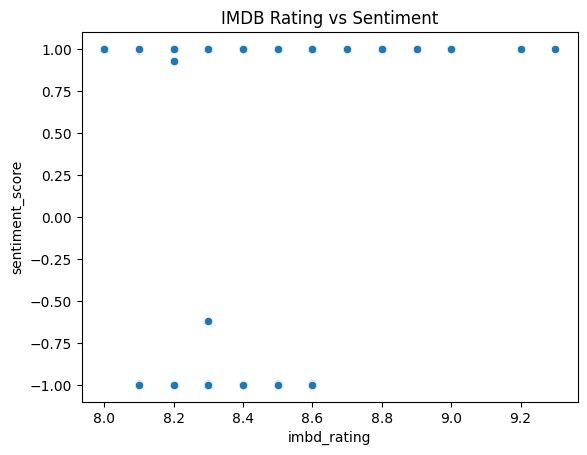

In [155]:
sns.scatterplot(x='imbd_rating', y='sentiment_score', data=data)

plt.title("IMDB Rating vs Sentiment")
plt.show()

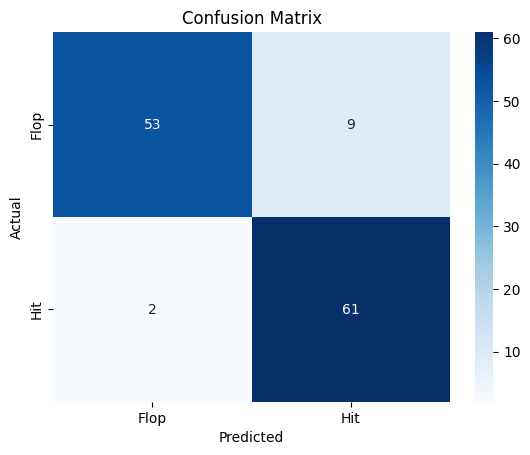

In [147]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Flop', 'Hit'],
            yticklabels=['Flop', 'Hit'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [148]:
scores = cross_val_score(model, X_scaled, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.5646709677419354


In [149]:
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df.head(10))

            Feature  Importance
0              year    0.324308
2          duration    0.191076
1       imbd_rating    0.152039
3       certificate    0.119783
4   sentiment_score    0.063120
11      genre_Drama    0.018252
6   genre_Adventure    0.016727
5      genre_Action    0.011831
21     genre_Sci-Fi    0.010569
10      genre_Crime    0.009211


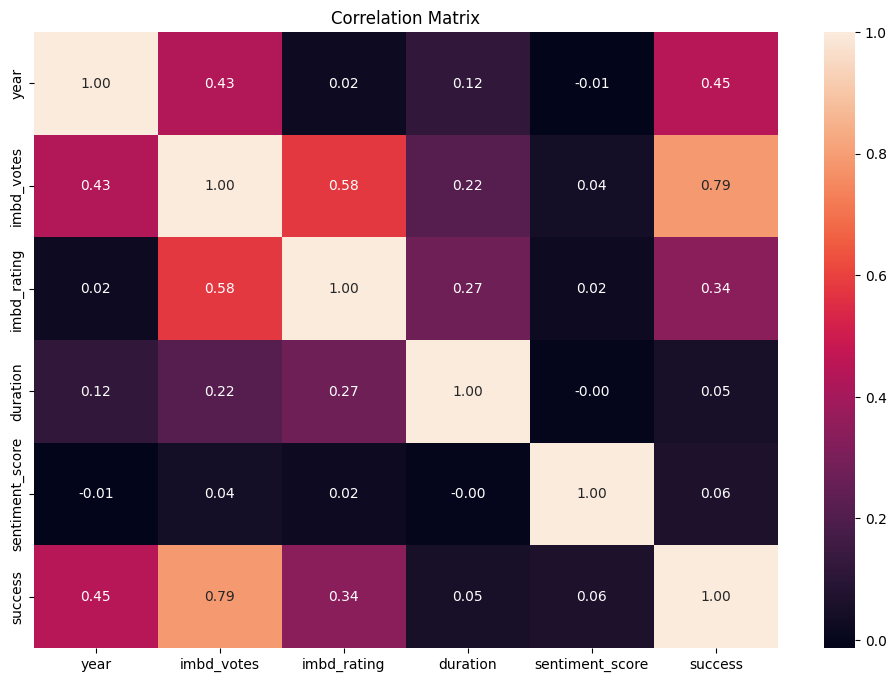

In [150]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [152]:
print("Final Model Summary")
print("-------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Model Summary
-------------------
Accuracy: 0.912

Confusion Matrix:
[[53  9]
 [ 2 61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.91        62
           1       0.87      0.97      0.92        63

    accuracy                           0.91       125
   macro avg       0.92      0.91      0.91       125
weighted avg       0.92      0.91      0.91       125



### Model Insights

- The model achieves ~78% accuracy
- It predicts successful movies with good recall
- Some false positives indicate overestimation of success
- Sentiment score positively influences movie success